<!-- dads-lab-header -->
<a href="https://colab.research.google.com/github/mdehghani86/DADS5250-GenAI/blob/main/labs/M01/M01_Lab2_Parameters_Tokens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #001a70 0%, #0055d4 100%); padding: 30px 36px; border-radius: 14px; margin-bottom: 20px;">
  <h1 style="color: #fff; margin: 0; font-size: 28px;">⚙️ M01 Lab 2 — Parameters & Tokens</h1>
  <p style="color: rgba(255,255,255,0.85); margin: 8px 0 0; font-size: 15px;">DADS 5250: Generative AI in Practice &nbsp;|&nbsp; Prof. Dehghani</p>
  <p style="color: rgba(255,255,255,0.65); margin: 6px 0 0; font-size: 13px;">⭐ Difficulty: Beginner &nbsp;|&nbsp; ⏱ Time: ~25 min</p>
</div>

> **📌 Note on models.** This lab references specific LLM versions through `DEFAULT_CHAT_MODEL` and `DEFAULT_MINI_MODEL` constants in the `dads5250` utility package. Models update quickly — feel free to swap to any newer OpenAI / Anthropic / Google model you have access to.


In [2]:
# === Shared lab setup: install dads5250 + load API key + sticky pill ===
# Installs the shared utilities (pp, pretty_print, lab_pill, model constants,
# setup_openai, setup_gemini) once per Colab runtime. The same OPENAI_API_KEY
# / GEMINI_API_KEY Colab secrets are used across every DADS 5250 lab — set
# them once in the 🔑 sidebar and they're picked up automatically.
import os
import importlib.util
if importlib.util.find_spec("dads5250") is None:
    !pip install -q "git+https://github.com/mdehghani86/DADS5250-GenAI.git#subdirectory=utils"

from dads5250 import (
    pp,
    pretty_print,
    lab_pill,
    setup_openai,
    setup_gemini,
    DEFAULT_CHAT_MODEL,   # newest reasoning model that supports temperature
    DEFAULT_MINI_MODEL,   # newest mini model that supports temperature
    DEFAULT_EMBED_MODEL,  # current embeddings default
    DEFAULT_GEMINI_MODEL, # tracks the latest stable flash
)

lab_pill('M01 Lab 2 — Parameters & Tokens')            # sticky banner so you always see which lab you're in
client = setup_openai()        # loads OPENAI_API_KEY + verifies it works


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.9 MB/s eta 0:00:00


OpenAI ready  |  model: gpt-5.4-mini  |  status: connected


<a href="https://colab.research.google.com/github/mdehghani86/AppliedGenAI/blob/main/ChatGPT_API_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color="#7C7965"># Applied Generative AI</font>
### Instructor: Prof. Dehghani

Welcome to the **Applied Generative AI** course. In this course, we will explore the foundations and applications of Generative AI using tools like OpenAI's API. By the end of this session, you will:

- 🟢 **Understand** how to set up and connect to OpenAI's API.  
- 🌟 **Learn** about the roles (System, Assistant, User) in prompt design.  
- ✨ **Generate** text, images, and vector embeddings programmatically.  
- 🔧 **Explore** fine-tuning to customize AI models for specific tasks.  

<font color="#BFBB9B">Let’s get started with setting up the OpenAI API!</font>


In [3]:
# Install the OpenAI Python SDK
# This library allows us to interact with OpenAI's API for text, images, and embeddings.
!pip install openai

In [4]:
from openai import OpenAI

# Import the OpenAI library for interacting with the API

# Set your OpenAI API key
# Replace "YOUR_API_KEY" with your actual key from OpenAI
# (api key handled by get_openai_key() in setup cell)

try:
    # Test the connection by sending a basic request to the GPT model
    response = client.chat.completions.create(
        model=DEFAULT_CHAT_MODEL,  # Specify the model to use
        messages=[{"role": "user", "content": "Connection test"}]  # Provide a simple test message
    )
    # Print success message if the API call works
    print("Connection successful!")
except Exception as e:
    # Print the error message if the API call fails
    print("Connection failed:", str(e))

Connection successful!


## 🎯 Prompt Playground: Understanding Roles

In OpenAI's API, you interact with the model using **roles**, which define the flow of the conversation:
- ➡️ **System**: Sets the behavior and tone of the assistant (e.g., "You are a cheerful assistant.").
- ➡️ **User**: Represents the input or question from the user (e.g., "What is AI?").
- ➡️ **Assistant**: Automatically generated responses based on the system and user inputs.

💡 **Why Roles Matter**:
Roles help control the assistant's personality and the quality of responses. For example:
- A system message like "You are a strict teacher" makes the assistant respond more formally.
- A system message like "You are a friendly chatbot" leads to casual responses.

Let’s see how these roles work in the next cell!

###Example 1: Without Assistant Role

In [5]:
# Demonstrating roles in OpenAI's API without the assistant role

# Define the conversation using only system and user roles
messages = [
    {"role": "system", "content": "You are a math tutor who explains problems step by step."},  # System role sets the behavior
    {"role": "user", "content": "Solve for x: 2x + 5 = 15"}  # User question
]

# Send the conversation to the API
response = client.chat.completions.create(
    model=DEFAULT_CHAT_MODEL,  # Use the chosen model
    messages=messages  # Pass the conversation
)

# Print the assistant's response
pretty_print(response.choices[0].message.content, title="Assistant's Response:")

###Example 2: With Assistant Role

In [6]:
# Demonstrating roles in OpenAI's API with the assistant role

# Define the conversation including a predefined assistant response
messages = [
    {"role": "system", "content": "You are a math tutor who explains problems step by step."},  # System role sets the behavior
    {"role": "user", "content": "Solve for x: 2x + 5 = 15"},  # User question
    {"role": "assistant", "content": "To solve for x: \n1. Subtract 5 from both sides: 2x = 10\n2. Divide both sides by 2: x = 5"}  # Predefined assistant response
]

# Send the conversation to the API
response = client.chat.completions.create(
    model=DEFAULT_CHAT_MODEL,  # Use the chosen model
    messages=messages  # Pass the conversation
)

# Print the assistant's response
pretty_print(response.choices[0].message.content, title="Assistant's Response:")

##🧮 Hands-On

In [7]:

# ++++ Hands-On: Complete the Roles ++++

# Define the conversation using the role structure
messages = [
    {"role": "system", "content": "You are a math tutor who explains concepts clearly and step by step."},  # Complete the system role
    {"role": "user", "content": "How do you calculate the arithmetic mean of a set of numbers?"},  # Complete the user role
    {"role": "assistant", "content": "To calculate the arithmetic mean:\n"
                                "1. Add all the numbers in the set.\n"
                                "2. Divide the sum by the number of numbers.\n\n"
                                "For example, for 10, 20, and 30:\n"
                                "Mean = (10 + 20 + 30) / 3 = 60 / 3 = 20."
                                }  # Optional predefined assistant response
]

# Uncomment the code below after completing the placeholders
response = client.chat.completions.create(
    model=DEFAULT_CHAT_MODEL,  # Specify the model
    messages=messages  # Pass the completed conversation
 )

pretty_print(response.choices[0].message.content, title="Assistant's Response:")


## 🎯 Function Playground: Simplify OpenAI API Calls

In OpenAI's API, you often send messages to get responses. Instead of repeating the call logic every time, you can use a function to streamline the process:
- ➡️ **Input**: A list of messages containing roles and content.
- ➡️ **Output**: The assistant's response as a string.

💡 **Why Use a Function**:  
Using a function keeps your code clean, reusable, and easy to maintain.

In [9]:
def Call_ChatGPT(messages, model=DEFAULT_CHAT_MODEL, max_tokens=100, temperature=0.7):
    """
    Send messages to the OpenAI API and get the assistant's response.

    Parameters:
    - messages (list): A list of message dictionaries with 'role' and 'content'.
    - model (str): The model to use (default is DEFAULT_CHAT_MODEL).
    - max_tokens (int): The maximum number of tokens to include in the response.
    - temperature (float): The sampling temperature (0.0 to 1.0, higher means more creative).

    Returns:
    - str: The assistant's response content.
    """
    try:
        response = client.chat.completions.create(
            model=model,
            messages=messages,
            max_completion_tokens=max_tokens,
            temperature=temperature
        )
        # Return the assistant's response
        return response.choices[0].message.content
    except Exception as e:
        return f"Error: {str(e)}"



In [10]:
# Example usage
messages = [
    {"role": "system", "content": "You are a helpful assistant who provides concise answers."},
    {"role": "user", "content": "What is the square root of 625?"}
]

# Call the function with optional parameters
response = Call_ChatGPT(messages, model=DEFAULT_CHAT_MODEL, max_tokens=50, temperature=0.5)

# Print the assistant's response
print("Assistant's Response:", response)


Assistant's Response: The principal square root of 625 is **25**.


## 🧮 Hands-On: Using `Call_ChatGPT`

### Task 1: Call the Function Without Adjusting Options
1. Define the **system role** (e.g., "You are a history expert").
2. Define the **user question** (e.g., "Who invented the telephone?").
3. Use the `Call_ChatGPT` function without modifying its options.
4. Run the cell and observe the response.

In [11]:
# ++++ Hands-On: Call ChatGPT Without Adjusting Options ++++

# Define the messages
messages = [
    {"role": "system", "content": "You are a history expert who provides brief responses."},
    {"role": "user", "content": "Who was the first President of the United States?"}
]

# Call the function without adjusting options
response = Call_ChatGPT(messages)

# Print the assistant's response
print("Assistant's Response:", response)


Assistant's Response: George Washington was the first President of the United States, serving from 1789 to 1797.


## 🧮 Hands-On: Using `Call_ChatGPT`
### Task 2: Call the Function With Custom Options
1. Define the **system role** and craft your own **user question**.
2. Adjust the optional parameters:
   - `model` (e.g., `"gpt-4"`),
   - `max_tokens` (e.g., `50`),
   - `temperature` (e.g., `0.5`).
3. Run the function and see how the custom options affect the response.


In [13]:
# ++++ Hands-On: Call ChatGPT With Custom Options ++++

# Define the messages
messages = [
    {"role": "system", "content": "You are a math expert who provides step-by-step solutions to complex problems."},
    {"role": "user", "content": "Solve the equation 3x^2 - 12x + 9 = 0 and explain each step."}
]


# Call the function with custom options
response = Call_ChatGPT(
    messages,
    model="gpt-4",         # Specify the model, e.g., DEFAULT_CHAT_MODEL
    max_tokens=300,      # Specify the max tokens, e.g., 50
    temperature=0.4      # Specify the temperature, e.g., 0.5
)

# Print the assistant's response
print("Assistant's Response:", response)


Assistant's Response: Sure, let's solve the quadratic equation 3x^2 - 12x + 9 = 0 step by step.

Step 1: Simplify the equation
The equation can be simplified by factoring out the greatest common factor (GCF) which in this case is 3. So, we get:

3(x^2 - 4x + 3) = 0

Step 2: Set the equation to zero
Since the product of 3 and the quantity (x^2 - 4x + 3) equals zero, one or both of them must be equal to zero. We already know that 3 is not equal to zero, so the quantity (x^2 - 4x + 3) must be equal to zero. So, we get:

x^2 - 4x + 3 = 0

Step 3: Factor the quadratic equation
The quadratic equation x^2 - 4x + 3 = 0 can be factored into (x - a)(x - b) = 0 where a and b are the roots of the equation. In this case, a and b are 1 and 3 because 1*3 = 3 (the constant term) and 1 + 3 = 4 (the coefficient of x). So, we get:

(x - 1)(x - 3) = 0

Step 4: Solve for x



## 🌄 OpenAI SDK: Generate an Image

In this section, we explore how to generate images using the **OpenAI SDK**. This functionality enables the creation of visuals from descriptive prompts, turning text-based ideas into compelling imagery.

### Key Steps:
1. **Craft a Prompt**: Write a detailed and imaginative description of the image you want to create.
   - Example: "A futuristic city with glowing skyscrapers, flying cars, and a vibrant sunset in the background."
2. **Generate the Image**: Use the OpenAI SDK to bring your prompt to life.
3. **Evaluate**: Analyze how well the generated image aligns with your prompt and reflect on potential refinements.

<font color="#BFBB9B">Let's turn ideas into visuals! 🖼️</font>


In [20]:
import openai
import base64

import requests
from PIL import Image
from IPython.display import display

def generate_and_display_images(prompt, n=1, size="1024x1024"):
    """
    Generate and display images using OpenAI's API.

    Parameters:
    - prompt (str): A detailed description of the desired image.
    - n (int): Number of images to generate (default is 1).
    - size (str): Dimensions of the image (e.g., "256x256", "512x512", or "1024x1024").
    - response_format (str): The format of the response, either "url" (default) or "b64_json".

    Displays:
    - Images directly in the notebook if response_format is "url".
    - Prints base64 strings if response_format is "b64_json".
    """
    try:
        # Generate the images
        response = client.images.generate(
            model="gpt-image-1",
            prompt=prompt,
            n=n,
            size=size
        )
        for i, item in enumerate(response.data):
            if item.b64_json:
                image_bytes = base64.b64decode(item.b64_json)

                filename = f"generated_image_{i+1}.png"
                with open(filename, "wb") as f:
                    f.write(image_bytes)

                img = Image.open(filename)
                display(img)

    except Exception as e:
        print(f"Error: {str(e)}")


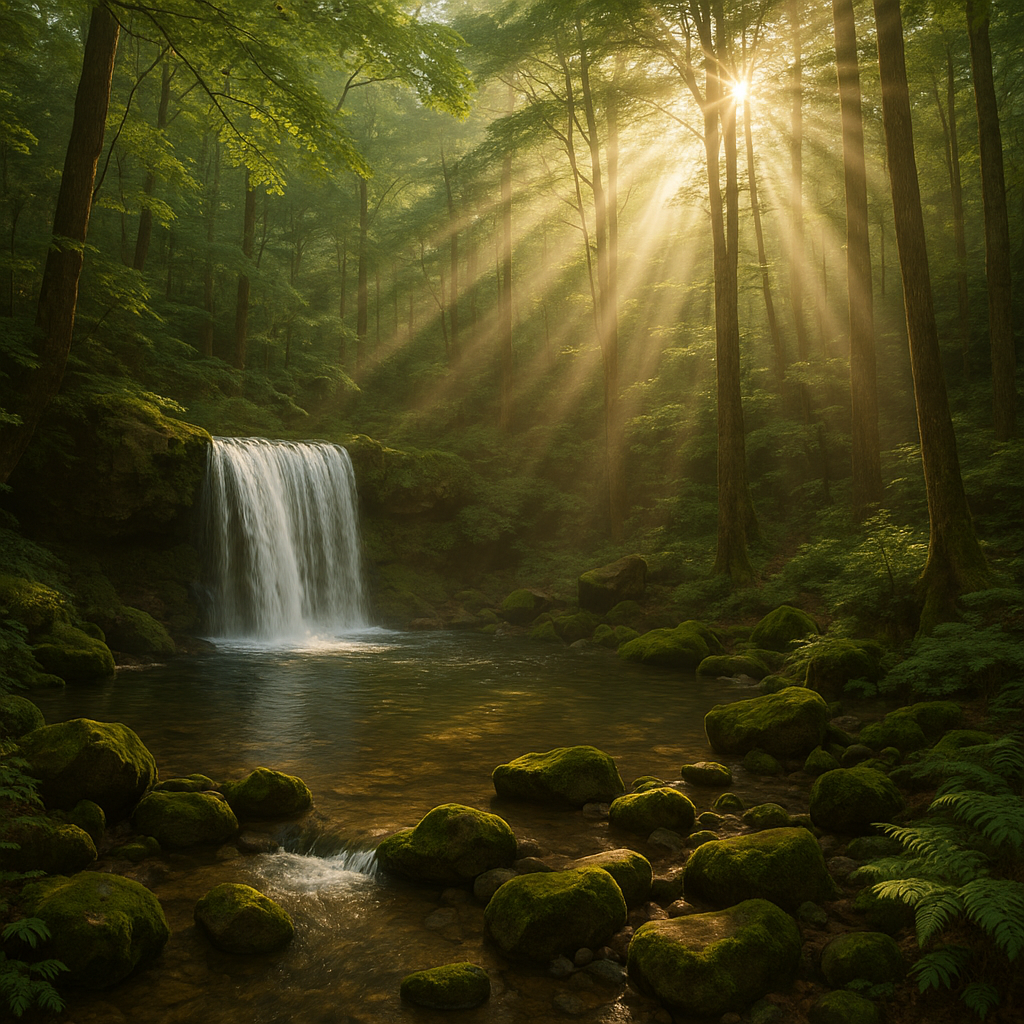

In [21]:
#Example 1
generate_and_display_images("A serene forest with a waterfall and sunlight streaming through the trees.")

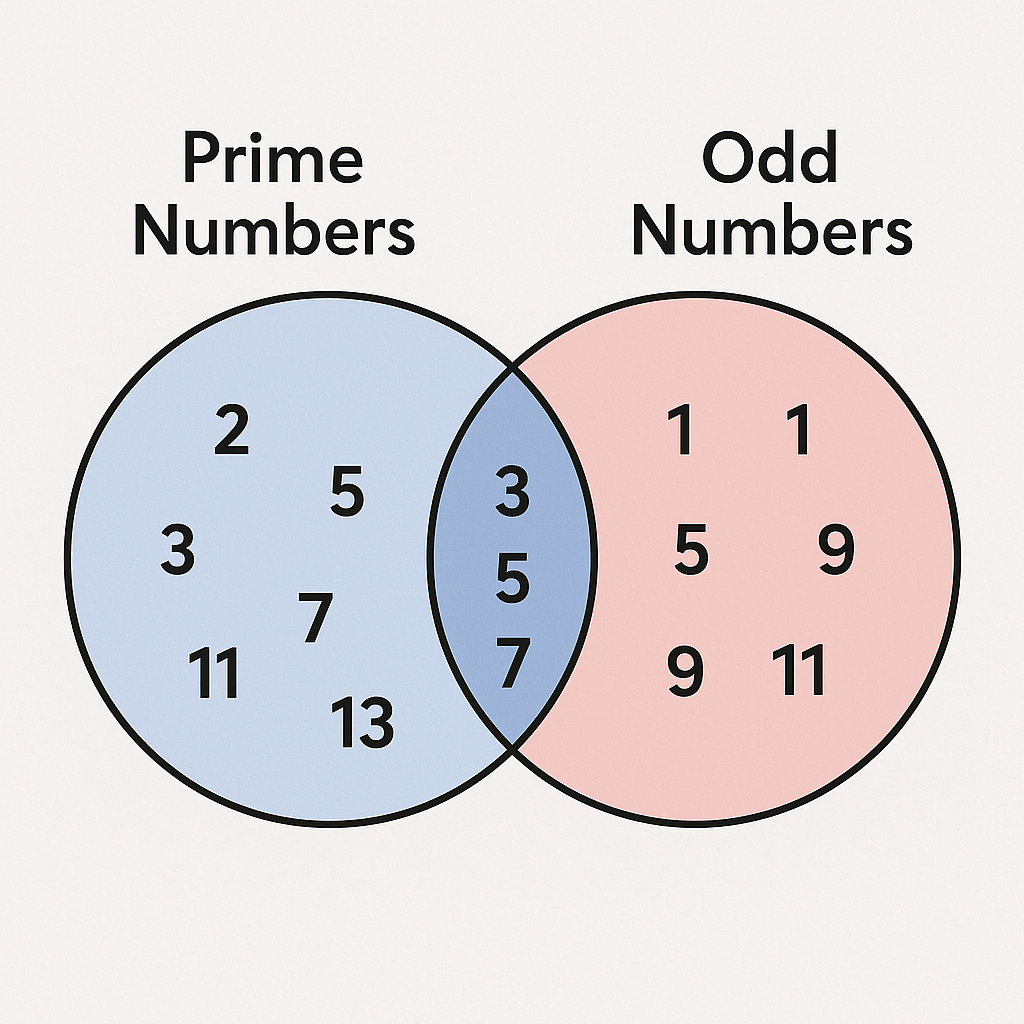

In [23]:
#Example 2
generate_and_display_images("Show a venn diagram to explain prime and odd numbers.", n=1, size="1024x1024")

## 🧠 Hands-On: Generate and Display Scientific Images

1. Define your scientific **prompt** (e.g., "The anatomy of the human eye showing the cornea, lens, and retina").
2. Set the **number of images** (`n`) and **size** (e.g., `"512x512"`).
3. Call the function to generate and display the image.

Fill in the placeholders and run the code below.


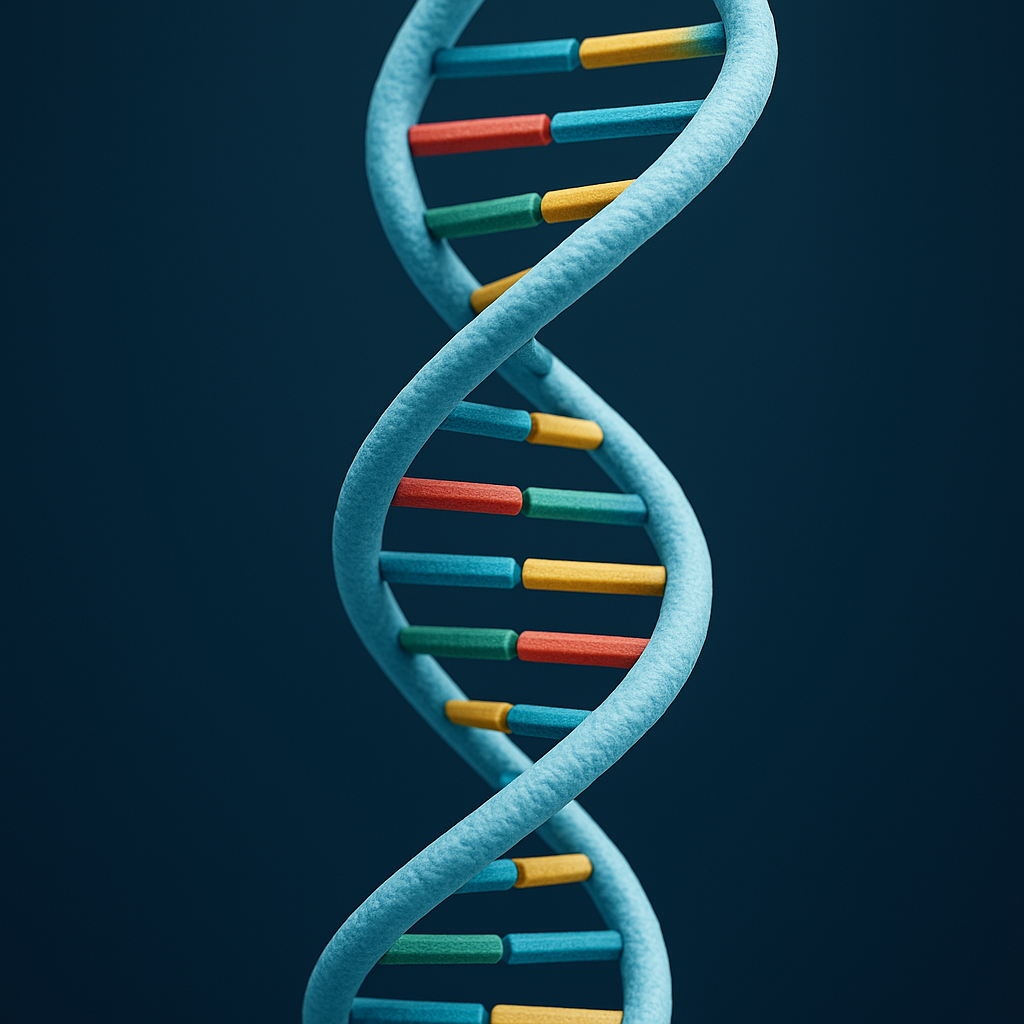

In [28]:
# Define the scientific prompt, number of images, and image size
prompt = "The structure of a DNA molecule showing the double helix"  # Example: "The structure of a DNA molecule showing the double helix"
n = 1  # Example: 1 or 2
size = "1024x1024"  # Example: "512x512"
#response_format = "url"  # "url" or "b64_json"

# Call the function with defined parameters
generate_and_display_images(prompt, n=n, size=size)


## 🎯 OpenAI SDK: Create Vector Embeddings

In OpenAI's API, you can create **vector embeddings**, which convert text into numerical representations that machines can process. These embeddings are useful for various applications like search, recommendation systems, and clustering.

- ➡️ **Text**: The input text you want to convert into a vector.
- ➡️ **Model**: The model used for creating embeddings (e.g., "text-embedding-3-small").
- ➡️ **Embeddings**: Numerical vectors representing the input text.

💡 **Why Vector Embeddings Matter**:  
Vector embeddings allow machines to understand text in a numerical format, enabling tasks like text similarity, semantic search, and clustering.

Let's explore how to generate vector embeddings in the next examples!

### Example 1: Create Vector Embedding for Text

In [29]:

# Example 1: Create a vector embedding for a single scientific sentence

# Define the text you want to convert into a vector embedding
text = "The water cycle involves processes like evaporation, condensation, and precipitation."

# Create the embedding using OpenAI's API
embedding = client.embeddings.create(input=text, model=DEFAULT_EMBED_MODEL)

# Print the generated embedding (vector) for the text
# The embedding is a list of numbers that represents the text in vector form
print(embedding.data[0].embedding)


[0.0005435943603515625, 0.045867919921875, 0.060577392578125, 0.009765625, -0.01849365234375, 0.053497314453125, 0.05572509765625, 0.0166473388671875, 0.006744384765625, 0.0296173095703125, 0.0321044921875, 0.0117645263671875, -0.0740966796875, -0.01543426513671875, -0.0003714561462402344, -0.008941650390625, -0.03021240234375, 0.035247802734375, -0.0335693359375, 0.052337646484375, -0.0175018310546875, 0.0034503936767578125, 0.0011348724365234375, 0.07379150390625, -0.00022864341735839844, -0.03118896484375, 0.00848388671875, 0.0245208740234375, -0.00437164306640625, 0.005313873291015625, 0.04168701171875, -0.01275634765625, -0.052459716796875, -0.0125274658203125, 0.042144775390625, -0.0216522216796875, -0.0254364013671875, 0.004482269287109375, -0.0447998046875, 0.02008056640625, -0.018157958984375, -0.0198211669921875, -0.05413818359375, -0.01264190673828125, 0.0027484893798828125, 0.020721435546875, -0.0203094482421875, 0.00600433349609375, 0.0009946823120117188, 0.02880859375, -0

In [30]:

# Example 2: Create vector embeddings for multiple scientific sentences

# Define a list of scientific sentences
texts = [
    "Photosynthesis is the process by which plants convert light energy into chemical energy.",
    "The theory of evolution by natural selection was proposed by Charles Darwin."
]

# Create the embeddings for all sentences using OpenAI's API
embeddings = client.embeddings.create(input=texts, model=DEFAULT_EMBED_MODEL)

# Print the embeddings for each sentence
# Each sentence will have its own vector representation
for i, emb in enumerate(embeddings.data):
    print(f"Embedding for Sentence {i + 1}: {emb.embedding[:10]}...")  # Print first 10 elements of the vector for brevity


Embedding for Sentence 1: [-0.0010547637939453125, 0.01409149169921875, -0.004207611083984375, 0.006839752197265625, 0.01396942138671875, 0.01641845703125, 0.02642822265625, -0.012542724609375, 0.03265380859375, -0.041534423828125]...
Embedding for Sentence 2: [0.076416015625, 0.0183258056640625, 0.03192138671875, 0.0245819091796875, -0.019378662109375, 0.0261688232421875, -0.0020427703857421875, -0.032440185546875, -0.038726806640625, 0.0006566047668457031]...


In [31]:

# Example 3: Demonstrating vector embeddings with text similarity

# Define two scientific sentences
text1 = "The Earth orbits around the Sun in an elliptical orbit."
text2 = "The Sun is the central star around which Earth revolves in an elliptical path."

# Generate vector embeddings for both sentences
embedding1 = client.embeddings.create(input=text1, model=DEFAULT_EMBED_MODEL)
embedding2 = client.embeddings.create(input=text2, model=DEFAULT_EMBED_MODEL)

# Extract the embeddings (vectors) for comparison
vector1 = embedding1.data[0].embedding
vector2 = embedding2.data[0].embedding

# Calculate the cosine similarity between the two vectors
import numpy as np
cosine_similarity = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))

# Print the cosine similarity (ranges from -1 to 1, where 1 means very similar)
print(f"Cosine Similarity between the two sentences: {cosine_similarity}")


Cosine Similarity between the two sentences: 0.7473441877872865


## 🧠 Hands-On: Working with Vector Embeddings

### Task 1: Generate a Vector Embedding for a Sentence
1. Define a scientific sentence (e.g., "The law of gravity states that every object attracts every other object").
2. Generate the vector embedding for this sentence.
3. Print the embedding to observe the numerical representation.

### Task 2: Measure Similarity Between Two Sentences
1. Define two scientific sentences (e.g., about physics).
2. Generate vector embeddings for both sentences.
3. Calculate and print the cosine similarity between the two embeddings.

Fill in the code below and run it to complete these tasks.


In [32]:
# Task 1: Generate vector embedding for a single scientific sentence

# Define the text for vector embedding
text = "The law of gravity states that every object attracts every other object."  # Example: "The law of gravity states that every object attracts every other object."

# Create the embedding using OpenAI's API
embedding = client.embeddings.create(input=text, model=DEFAULT_EMBED_MODEL)

# Print the generated embedding (vector)
print(embedding.data[0].embedding)



[-0.00390625, 0.01113128662109375, 0.0265655517578125, 0.0279083251953125, 0.0262603759765625, 0.00670623779296875, -0.0092926025390625, -0.0163726806640625, -0.04071044921875, -0.032501220703125, -0.0517578125, 0.0010290145874023438, -0.02911376953125, 0.0171661376953125, 0.0064544677734375, 0.0248260498046875, 0.01448822021484375, -0.0031280517578125, 0.034149169921875, -0.0172271728515625, -0.019500732421875, -0.0211029052734375, 0.03375244140625, 0.00389862060546875, -0.0173797607421875, -0.0704345703125, 0.03741455078125, 0.01499176025390625, 0.0285186767578125, 0.05657958984375, 0.050994873046875, -0.0284576416015625, -0.01113128662109375, 0.0160369873046875, 0.029876708984375, 0.062744140625, 0.0240325927734375, -0.01183319091796875, -0.007476806640625, 0.00937652587890625, 0.028839111328125, 0.00997161865234375, 0.005832672119140625, -0.0262298583984375, -0.035430908203125, 0.0235748291015625, 0.02020263671875, -0.0185394287109375, -0.0304412841796875, 0.01502227783203125, -0.0

In [33]:
# Task 2: Measure similarity between two scientific sentences

# Define two scientific sentences
text1 = "Newton's laws of motion describe the relationship between a body and the forces acting on it."  # Example: "Newton's laws of motion describe the relationship between a body and the forces acting on it."
text2 = "The force of an object is equal to its mass times acceleration."  # Example: "The force of an object is equal to its mass times acceleration."

# Generate vector embeddings for both sentences
embedding1 = client.embeddings.create(input=text1, model=DEFAULT_EMBED_MODEL)
embedding2 = client.embeddings.create(input=text2, model=DEFAULT_EMBED_MODEL)

# Extract the embeddings (vectors) for comparison
vector1 = embedding1.data[0].embedding
vector2 = embedding2.data[0].embedding

# Calculate the cosine similarity between the two vectors
import numpy as np
cosine_similarity = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))

# Print the cosine similarity (ranges from -1 to 1, where 1 means very similar)
print(f"Cosine Similarity between the two sentences: {cosine_similarity}")

Cosine Similarity between the two sentences: 0.44371568492655317
